# Classification with Linear Probing – Independent Modalities
This notebook trains a linear classifier on each modality independently.
Each dataset section follows the same three-scenario protocol:
1. **Baseline** – full original CLIP embeddings
2. **Original filtered** – original embeddings restricted to the selected dimensions
3. **Aligned filtered** – subspace-aligned embeddings restricted to the selected dimensions

## MSRVTT v2 (Unique Videos, First Caption)

In [1]:
import copy
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

try:
    import wandb
except ImportError as exc:
    raise ImportError("wandb is required. Install with `pip install wandb`.") from exc

import sys
sys.path.append(os.path.abspath(".."))

from dataset.msrvtt.msrvtt_dataloaderv2 import (
    MSRVTTEmbeddingsDatasetV2,
    msrvtt_v2_collate_fn,
)
from subspace_alignment.subspace_alignment import (
    fit_subspace_alignment,
    apply_subspace_alignment,
    analyze_subspace_dimensions,
)
from analysis.modality_gap import compute_gap
from metrics.retrieval import compute_retrieval
from metrics.clustering import clustering_metrics_two_modalities_msrvtt
from models.fusion_mlp_classifier import LinearProbingIndependentModalities

# ── Seed ──
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

# ── Device ──
DEVICE = os.environ.get("MSRVTT_CLS_DEVICE", "cuda:1" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ── Paths (v2) ──
PRECOMPUTED_TRAIN_DIR = "/mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k_v2/precomputed_train"
PRECOMPUTED_TEST_DIR  = "/mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k_v2/precomputed_test"

# ── Hyper-parameters ──
BATCH_SIZE = 256
NUM_WORKERS = 0
D_SUB = 256
CLASSIFIER_EPOCHS = 200
CLASSIFIER_PATIENCE = 20
MAX_LR = 3e-4
WEIGHT_DECAY = 1e-4

# ── W&B ──
WANDB_ENABLED = True
WANDB_PROJECT = "msrvtt_v2_clip_classifier"
WANDB_GROUP   = "msrvtt_v2_linear_probe_independent"

BASE_SAVE_DIR = Path("msrvtt_v2_classification_runs")
BASE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

GAP_NAMES = ["RMG", "L2M", "L2I", "cosineTP"]

MSRVTT_V2_SEARCH_CFG = {
    "n_trials": 100,
    "seed": 0,
    "max_eval_batches": 40,
    "max_cluster_samples": 3000,
    "min_dims": 16,
    "direction": "text_to_vision",
    "n_clusters": 20,
}


/opt/anaconda3/envs/few_dim_modalitygap/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [3]:
def label_to_int(label):
    if isinstance(label, torch.Tensor):
        return int(label.item())
    if isinstance(label, np.ndarray):
        return int(label.item())
    return int(label)

def extract_labels_from_dataset(dataset, desc="labels"):
    labels = []
    for idx in tqdm(range(len(dataset)), desc=desc):
        item = dataset[idx]
        if len(item) < 3:
            raise ValueError("Dataset must return at least (text, vision, label).")
        labels.append(label_to_int(item[2]))
    return np.asarray(labels, dtype=np.int64)

def gap_to_float(x):
    if isinstance(x, dict):
        if "text_vision" in x:
            return float(x["text_vision"])
        return float(next(iter(x.values())))
    if isinstance(x, torch.Tensor):
        return float(x.item())
    if hasattr(x, "item"):
        return float(x.item())
    return float(x)

def normalize01(v, eps=1e-12):
    v = np.asarray(v, dtype=np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)

def get_dims_gap(loader, max_samples=20_000, device="cuda"):
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Collecting up to {max_samples} train pairs"):
            text_b, vis_b = batch[:2]
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()
            Xs.append(text_b)
            Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break
    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]
    mu_x = X.mean(axis=0)
    mu_y = Y.mean(axis=0)
    gap_dim = np.abs(mu_x - mu_y)
    top_gap = np.argsort(-gap_dim)
    return normalize01(gap_dim), top_gap

def select_dims(importance, gap, imp_thr, gap_thr, min_dims=16):
    idx = np.where((importance >= imp_thr) & (gap <= gap_thr))[0]
    if idx.size < min_dims:
        order = np.argsort(-importance)
        idx = order[:min_dims]
    return np.sort(idx)

# ── Build datasets and loaders ──
ds_train_v2 = MSRVTTEmbeddingsDatasetV2(
    PRECOMPUTED_TRAIN_DIR,
    split_name="train_shard",
    return_metadata=False,
)

ds_test_v2 = MSRVTTEmbeddingsDatasetV2(
    PRECOMPUTED_TEST_DIR,
    split_name="test_shard",
    return_metadata=False,
)

train_loader_v2 = DataLoader(
    ds_train_v2,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=msrvtt_v2_collate_fn,
)

test_loader_v2 = DataLoader(
    ds_test_v2,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=msrvtt_v2_collate_fn,
)

embedding_dim_v2 = int(ds_train_v2[0][0].shape[-1])
num_classes_v2 = len(set(extract_labels_from_dataset(ds_train_v2, desc="Extracting train labels (v2)")))

label_lut_v2 = {label: idx for idx, label in enumerate(
    sorted(set(extract_labels_from_dataset(ds_train_v2, desc="Building label LUT (v2)")))
)}
label_lut_cpu_v2 = torch.tensor(
    [label_lut_v2[label] for label in sorted(label_lut_v2.keys())],
    dtype=torch.long,
)

print(f"Train samples (v2): {len(ds_train_v2)}")
print(f"Test samples  (v2): {len(ds_test_v2)}")
print(f"Number of classes : {num_classes_v2}")
print(f"Embedding dim     : {embedding_dim_v2}")


[MSRVTTv2] 7010 unique videos from /mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k_v2/precomputed_train | vision_emb=(7010, 512) | text_emb=(7010, 512) | num_classes=20
[MSRVTTv2] 1000 unique videos from /mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k_v2/precomputed_test | vision_emb=(1000, 512) | text_emb=(1000, 512) | num_classes=20


Building label LUT (v2): 100%|██████████| 7010/7010 [00:00<00:00, 303561.65it/s]

Train samples (v2): 7010
Test samples  (v2): 1000
Number of classes : 20
Embedding dim     : 512


Fitting MSRVTT v2 subspace alignment model...


Collected 7010 samples of dimension 512, these will be used to fit the subspace alignment model with d_sub=256.


Best MSRVTT v2 thresholds:
  imp_thr: 0.1357
  gap_thr: 0.469
  selected_dims: 508
  removed_dims: 4
  best_score: 0.7659786743215288
  retrieval_orig@1: 0.4910762384533882
  retrieval_aligned@1: 0.4571996256709099
  v_measure_orig: 0.27335334754893176
  v_measure_aligned: 0.31032813696982775
First 20 selected dims: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
First 20 removed dims : [70, 152, 253, 307]


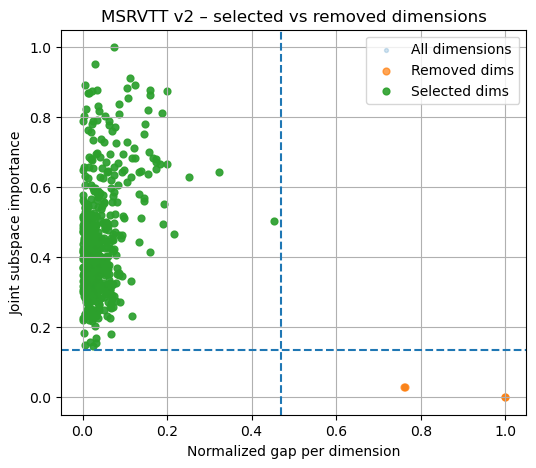

In [4]:
def eval_thresholds_msrvtt_v2(
    imp_thr,
    gap_thr,
    test_loader,
    sub_model,
    important_joint_dims,
    gap_dims,
    device="cuda",
    max_eval_batches=None,
    max_cluster_samples=3000,
    n_clusters=20,
    direction="text_to_vision",
    min_dims=16,
):
    idx = select_dims(important_joint_dims, gap_dims, imp_thr, gap_thr, min_dims=min_dims)

    r_orig    = {1: [], 5: [], 10: []}
    r_aligned = {1: [], 5: [], 10: []}
    gaps_orig_batches    = {g: [] for g in GAP_NAMES}
    gaps_aligned_batches = {g: [] for g in GAP_NAMES}

    Xt_buf, Xv_buf, Xv_al_buf, labels_buf = [], [], [], []
    seen = 0
    n_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="MSRVTT v2 threshold evaluation", leave=False):
            text_b, vis_b, labels = batch[:3]
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device),  dim=-1)

            if direction == "vision_to_text":
                X, Y = Y, X

            Xs = X[:, idx]
            Ys = Y[:, idx]

            r_orig[1].append(gap_to_float(compute_retrieval("msrvtt", (Xs, Ys), top_k=1)))
            r_orig[5].append(gap_to_float(compute_retrieval("msrvtt", (Xs, Ys), top_k=5)))
            r_orig[10].append(gap_to_float(compute_retrieval("msrvtt", (Xs, Ys), top_k=10)))

            Xn, _, Yaln = apply_subspace_alignment(X, Y, sub_model)
            Xal_s = Xn[:, idx]
            Yal_s = Yaln[:, idx]

            r_aligned[1].append(gap_to_float(compute_retrieval("msrvtt", (Xal_s, Yal_s), top_k=1)))
            r_aligned[5].append(gap_to_float(compute_retrieval("msrvtt", (Xal_s, Yal_s), top_k=5)))
            r_aligned[10].append(gap_to_float(compute_retrieval("msrvtt", (Xal_s, Yal_s), top_k=10)))

            for gap_name in GAP_NAMES:
                gaps_orig_batches[gap_name].append(
                    gap_to_float(compute_gap(gap_name, Xs, Ys, iterations=None))
                )
                gaps_aligned_batches[gap_name].append(
                    gap_to_float(compute_gap(gap_name, Xal_s, Yal_s, iterations=None))
                )

            if labels is not None and seen < max_cluster_samples:
                labels_t = torch.as_tensor(labels)
                b = min(Xs.shape[0], max_cluster_samples - seen)
                Xt_buf.append(Xs[:b].detach().cpu())
                Xv_buf.append(Ys[:b].detach().cpu())
                Xv_al_buf.append(Yal_s[:b].detach().cpu())
                labels_buf.append(labels_t[:b].detach().cpu())
                seen += b

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    clustering_orig = None
    clustering_aligned = None
    if labels_buf:
        Xt_all     = torch.cat(Xt_buf, dim=0)
        Xv_all     = torch.cat(Xv_buf, dim=0)
        Xv_al_all  = torch.cat(Xv_al_buf, dim=0)
        labels_all = torch.cat(labels_buf, dim=0)
        clustering_orig = clustering_metrics_two_modalities_msrvtt(
            Xt_all, Xv_all, labels_all, n_clusters=n_clusters
        )
        clustering_aligned = clustering_metrics_two_modalities_msrvtt(
            Xt_all, Xv_al_all, labels_all, n_clusters=n_clusters
        )

    return {
        "n_dims":             int(idx.size),
        "dim_idx":            idx,
        "retrieval_orig":     {k: float(np.mean(v)) for k, v in r_orig.items()},
        "retrieval_aligned":  {k: float(np.mean(v)) for k, v in r_aligned.items()},
        "gaps_orig":          {g: float(np.mean(v)) for g, v in gaps_orig_batches.items()},
        "gaps_aligned":       {g: float(np.mean(v)) for g, v in gaps_aligned_batches.items()},
        "clustering_orig":    clustering_orig,
        "clustering_aligned": clustering_aligned,
    }

# ── Fit subspace alignment on training data ──
print("Fitting MSRVTT v2 subspace alignment model...")
sub_model_v2 = fit_subspace_alignment(train_loader_v2, n_fit=10_000, d_sub=D_SUB, device=DEVICE)

important_dims_txt_v2, important_dims_vid_v2, important_joint_dims_v2 = analyze_subspace_dimensions(
    sub_model_v2, device=DEVICE,
)
gap_dims_v2, top_gap_idx_v2 = get_dims_gap(train_loader_v2, device=DEVICE)

# ── Thresholds from few_dimensions.ipynb MSRVTT v2 Optuna search ──
imp_thr_v2 = 0.1357
gap_thr_v2 = 0.4690

metrics_v2 = eval_thresholds_msrvtt_v2(
    imp_thr=imp_thr_v2,
    gap_thr=gap_thr_v2,
    test_loader=test_loader_v2,
    sub_model=sub_model_v2,
    important_joint_dims=important_joint_dims_v2,
    gap_dims=gap_dims_v2,
    device=DEVICE,
    max_eval_batches=MSRVTT_V2_SEARCH_CFG["max_eval_batches"],
    max_cluster_samples=MSRVTT_V2_SEARCH_CFG["max_cluster_samples"],
    n_clusters=MSRVTT_V2_SEARCH_CFG["n_clusters"],
    direction=MSRVTT_V2_SEARCH_CFG["direction"],
    min_dims=MSRVTT_V2_SEARCH_CFG["min_dims"],
)

r1_orig_v2    = metrics_v2["retrieval_orig"][1]
r1_aligned_v2 = metrics_v2["retrieval_aligned"][1]
v_orig_v2    = metrics_v2["clustering_orig"]["V-measure"]    if metrics_v2["clustering_orig"]    else 0.0
v_aligned_v2 = metrics_v2["clustering_aligned"]["V-measure"] if metrics_v2["clustering_aligned"] else 0.0

selected_dims_v2   = np.asarray(metrics_v2["dim_idx"], dtype=np.int64)
removed_dims_v2    = np.setdiff1d(np.arange(embedding_dim_v2), selected_dims_v2)
selected_dims_v2_t = torch.as_tensor(selected_dims_v2, dtype=torch.long, device=DEVICE)

dimension_search_summary_v2 = {
    "imp_thr":             imp_thr_v2,
    "gap_thr":             gap_thr_v2,
    "selected_dims":       int(selected_dims_v2.size),
    "removed_dims":        int(removed_dims_v2.size),
    "best_score":          0.5 * (r1_orig_v2 + r1_aligned_v2) + 0.5 * (v_orig_v2 + v_aligned_v2),
    "retrieval_orig@1":    float(r1_orig_v2),
    "retrieval_aligned@1": float(r1_aligned_v2),
    "v_measure_orig":      float(v_orig_v2),
    "v_measure_aligned":   float(v_aligned_v2),
}

print("Best MSRVTT v2 thresholds:")
for key, value in dimension_search_summary_v2.items():
    print(f"  {key}: {value}")

print("First 20 selected dims:", selected_dims_v2[:20].tolist())
print("First 20 removed dims :", removed_dims_v2[:20].tolist())

plt.figure(figsize=(6, 5))
plt.scatter(gap_dims_v2, important_joint_dims_v2, s=8, alpha=0.2, label="All dimensions")
removed_mask_v2 = np.ones_like(gap_dims_v2, dtype=bool)
removed_mask_v2[selected_dims_v2] = False
plt.scatter(gap_dims_v2[removed_mask_v2], important_joint_dims_v2[removed_mask_v2],
            s=24, alpha=0.7, label="Removed dims")
plt.scatter(gap_dims_v2[selected_dims_v2], important_joint_dims_v2[selected_dims_v2],
            s=24, alpha=0.9, label="Selected dims")
plt.axvline(gap_thr_v2, linestyle="--")
plt.axhline(imp_thr_v2, linestyle="--")
plt.xlabel("Normalized gap per dimension")
plt.ylabel("Joint subspace importance")
plt.title("MSRVTT v2 \u2013 selected vs removed dimensions")
plt.grid(True)
plt.legend()
plt.show()


In [5]:
def make_optimizer_and_scheduler(model, train_loader, epochs=200, max_lr=3e-4, weight_decay=1e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=max_lr,
        epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,
        div_factor=25.0,
        final_div_factor=1e4,
        anneal_strategy="cos",
    )
    return optimizer, scheduler

def remap_labels(labels_gpu, lut_gpu):
    if labels_gpu.numel() == 0:
        return labels_gpu
    if labels_gpu.min().item() < 0 or labels_gpu.max().item() >= lut_gpu.numel():
        raise ValueError(
            f"Labels out of LUT range. min={labels_gpu.min().item()} "
            f"max={labels_gpu.max().item()} lut_size={lut_gpu.numel()}"
        )
    mapped = lut_gpu[labels_gpu]
    if (mapped < 0).any():
        bad = labels_gpu[mapped < 0][:20].detach().cpu().numpy()
        raise ValueError(f"Found labels missing from the train label map. Examples: {bad}")
    return mapped

def prepare_features_for_scenario(
    text_emb, vision_emb, scenario_mode,
    selected_dims=None, sub_model=None, device="cuda",
):
    if scenario_mode == "baseline":
        return text_emb, vision_emb
    if selected_dims is None:
        raise ValueError("selected_dims must be provided for filtered scenarios.")
    if scenario_mode == "original_filtered":
        return (
            text_emb.index_select(dim=1, index=selected_dims),
            vision_emb.index_select(dim=1, index=selected_dims),
        )
    if scenario_mode == "aligned_filtered":
        if sub_model is None:
            raise ValueError("sub_model required for aligned scenario.")
        X_al, _, Y_al = apply_subspace_alignment(text_emb, vision_emb, sub_model)
        return (
            X_al.index_select(dim=1, index=selected_dims),
            Y_al.index_select(dim=1, index=selected_dims),
        )
    raise ValueError(f"Unknown scenario_mode: {scenario_mode}")


def train_linear_probe_v2_independent(
    scenario_name,
    scenario_mode,
    train_loader,
    test_loader,
    num_classes,
    feature_dim,
    device="cuda",
    selected_dims=None,
    sub_model=None,
    epochs=200,
    patience=20,
    max_lr=3e-4,
    weight_decay=1e-4,
    wandb_enabled=True,
    wandb_project="msrvtt_v2_clip_classifier",
    wandb_group="msrvtt_v2_linear_probe_independent",
    extra_config=None,
):
    scenario_dir = BASE_SAVE_DIR / scenario_name
    scenario_dir.mkdir(parents=True, exist_ok=True)

    model = LinearProbingIndependentModalities(d=feature_dim, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(device)
    optimizer, scheduler = make_optimizer_and_scheduler(
        model, train_loader, epochs=epochs, max_lr=max_lr, weight_decay=weight_decay,
    )

    lut_gpu = label_lut_cpu_v2.to(device)
    selected_dims_t = None
    if selected_dims is not None:
        selected_dims_t = torch.as_tensor(selected_dims, dtype=torch.long, device=device)

    run_config = {
        "scenario_name": scenario_name,
        "scenario_mode": scenario_mode,
        "feature_dim": int(feature_dim),
        "num_classes": int(num_classes),
        "epochs": int(epochs),
        "patience": int(patience),
        "max_lr": float(max_lr),
        "weight_decay": float(weight_decay),
        "d_sub": int(D_SUB),
        "selected_dims_count": int(len(selected_dims)) if selected_dims is not None else int(embedding_dim_v2),
        "independent_modalities": True,
        "dataset_version": "msrvtt_v2",
    }
    if extra_config is not None:
        run_config.update(extra_config)

    run = None
    if wandb_enabled:
        run = wandb.init(
            project=wandb_project,
            group=wandb_group,
            name=scenario_name,
            config=run_config,
            reinit=True,
        )

    history = {
        "train": {"loss": [], "accuracy": [], "lr": [], **{g: [] for g in GAP_NAMES}},
        "test":  {"loss": [], "accuracy": [], **{g: [] for g in GAP_NAMES}},
    }

    best_test_loss = float("inf")
    best_test_acc  = 0.0
    best_loss_state = None
    best_acc_state  = None
    epochs_no_improve = 0

    def run_epoch(dataloader, phase):
        is_train = phase == "train"
        model.train() if is_train else model.eval()
        losses, accs, lrs = [], [], []
        gap_values = {g: [] for g in GAP_NAMES}

        for batch in tqdm(dataloader, desc=f"{scenario_name} | {phase}", leave=False):
            text_emb, vision_emb, labels = batch[:3]
            text_emb   = text_emb.to(device=device, dtype=torch.float32, non_blocking=True)
            vision_emb = vision_emb.to(device=device, dtype=torch.float32, non_blocking=True)
            labels = torch.as_tensor(labels, device=device, dtype=torch.long)
            labels = remap_labels(labels, lut_gpu)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            text_feat, vision_feat = prepare_features_for_scenario(
                text_emb, vision_emb,
                scenario_mode=scenario_mode,
                selected_dims=selected_dims_t,
                sub_model=sub_model,
                device=device,
            )

            # Independent modality: each modality is its own sample
            all_emb    = torch.cat([text_feat, vision_feat], dim=0)   # (2B, d)
            all_labels = torch.cat([labels, labels], dim=0)           # (2B,)

            logits = model(all_emb)                                   # (2B, C)
            loss = criterion(logits, all_labels)

            if is_train:
                loss.backward()
                clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            acc = (logits.argmax(dim=1) == all_labels).float().mean()
            losses.append(float(loss.item()))
            accs.append(float(acc.item()))
            if is_train:
                lrs.append(float(optimizer.param_groups[0]["lr"]))

            with torch.no_grad():
                for gap_name in GAP_NAMES:
                    gap_values[gap_name].append(
                        gap_to_float(compute_gap(gap_name, text_feat.detach(), vision_feat.detach(), iterations=None))
                    )

        mean_loss = float(np.mean(losses)) if losses else float("nan")
        mean_acc  = float(np.mean(accs))   if accs   else float("nan")
        mean_lr   = float(np.mean(lrs))    if (is_train and lrs) else None
        mean_gaps = {g: float(np.mean(v))  for g, v in gap_values.items()}
        return mean_loss, mean_acc, mean_lr, mean_gaps

    for epoch in range(epochs):
        train_loss, train_acc, train_lr, train_gaps = run_epoch(train_loader, phase="train")
        with torch.no_grad():
            test_loss, test_acc, _, test_gaps = run_epoch(test_loader, phase="test")

        history["train"]["loss"].append(train_loss)
        history["train"]["accuracy"].append(train_acc)
        history["train"]["lr"].append(train_lr if train_lr is not None else float("nan"))
        for g in GAP_NAMES:
            history["train"][g].append(train_gaps[g])

        history["test"]["loss"].append(test_loss)
        history["test"]["accuracy"].append(test_acc)
        for g in GAP_NAMES:
            history["test"][g].append(test_gaps[g])

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(
                f"[{scenario_name}] epoch {epoch+1}/{epochs} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}"
            )

        improved = False
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_loss_state = copy.deepcopy(model.state_dict())
            improved = True
            torch.save({
                "epoch": epoch + 1, "metric": "test_loss",
                "metric_value": best_test_loss,
                "model_state_dict": best_loss_state,
                "config": run_config,
            }, scenario_dir / "best_model_test_loss.pt")

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_acc_state = copy.deepcopy(model.state_dict())
            improved = True
            torch.save({
                "epoch": epoch + 1, "metric": "test_accuracy",
                "metric_value": best_test_acc,
                "model_state_dict": best_acc_state,
                "config": run_config,
            }, scenario_dir / "best_model_test_acc.pt")

        if improved:
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if run is not None:
            payload = {
                "epoch": epoch + 1,
                "train/loss": train_loss, "train/accuracy": train_acc, "train/lr": train_lr,
                "test/loss": test_loss, "test/accuracy": test_acc,
                "best/test_loss": best_test_loss, "best/test_accuracy": best_test_acc,
                "early_stop/epochs_no_improve": epochs_no_improve,
            }
            for g in GAP_NAMES:
                payload[f"train/{g}"] = train_gaps[g]
                payload[f"test/{g}"]  = test_gaps[g]
            wandb.log(payload)

        if epochs_no_improve >= patience:
            print(f"[{scenario_name}] early stop at epoch {epoch+1}/{epochs}")
            break

    if best_acc_state is not None:
        model.load_state_dict(best_acc_state)
        best_checkpoint_metric = "test_accuracy"
    elif best_loss_state is not None:
        model.load_state_dict(best_loss_state)
        best_checkpoint_metric = "test_loss"
    else:
        best_checkpoint_metric = "last_epoch"

    with torch.no_grad():
        final_train_loss, final_train_acc, _, final_train_gaps = run_epoch(train_loader, phase="test")
        final_test_loss,  final_test_acc,  _, final_test_gaps  = run_epoch(test_loader,  phase="test")

    result = {
        "scenario_name": scenario_name,
        "scenario_mode": scenario_mode,
        "feature_dim": int(feature_dim),
        "selected_dims_count": int(len(selected_dims)) if selected_dims is not None else int(embedding_dim_v2),
        "removed_dims_count": int(embedding_dim_v2 - len(selected_dims)) if selected_dims is not None else 0,
        "best_checkpoint_metric": best_checkpoint_metric,
        "best_test_loss": float(best_test_loss),
        "best_test_acc": float(best_test_acc),
        "final_train_loss": float(final_train_loss),
        "final_train_acc": float(final_train_acc),
        "final_test_loss": float(final_test_loss),
        "final_test_acc": float(final_test_acc),
        "final_train_gaps": {k: float(v) for k, v in final_train_gaps.items()},
        "final_test_gaps":  {k: float(v) for k, v in final_test_gaps.items()},
        "history": history,
        "checkpoint_dir": str(scenario_dir),
    }

    with open(scenario_dir / "summary.json", "w") as f:
        json.dump(result, f, indent=2)

    torch.save({
        "model_state_dict": model.state_dict(),
        "result": result,
        "config": run_config,
    }, scenario_dir / "best_model_loaded_final.pt")

    if run is not None:
        run.summary["best_test_loss"]      = result["best_test_loss"]
        run.summary["best_test_acc"]       = result["best_test_acc"]
        run.summary["final_train_acc"]     = result["final_train_acc"]
        run.summary["final_test_acc"]      = result["final_test_acc"]
        run.summary["selected_dims_count"] = result["selected_dims_count"]
        run.summary["removed_dims_count"]  = result["removed_dims_count"]
        for g in GAP_NAMES:
            run.summary[f"final_train_{g}"] = result["final_train_gaps"][g]
            run.summary[f"final_test_{g}"]  = result["final_test_gaps"][g]
        run.finish()

    print(
        f"[{scenario_name}] done | best_test_acc={result['best_test_acc']:.4f} | "
        f"final_test_acc={result['final_test_acc']:.4f}"
    )
    return result


def build_summary_table(results_dict):
    rows = []
    for scenario_name, result in results_dict.items():
        row = {
            "scenario": scenario_name,
            "feature_dim": result["feature_dim"],
            "selected_dims": result["selected_dims_count"],
            "removed_dims": result["removed_dims_count"],
            "best_test_acc": result["best_test_acc"],
            "best_test_loss": result["best_test_loss"],
            "final_train_acc": result["final_train_acc"],
            "final_test_acc": result["final_test_acc"],
            "final_train_loss": result["final_train_loss"],
            "final_test_loss": result["final_test_loss"],
        }
        for g in GAP_NAMES:
            row[f"train_{g}"] = result["final_train_gaps"][g]
            row[f"test_{g}"]  = result["final_test_gaps"][g]
        rows.append(row)
    return pd.DataFrame(rows).sort_values("scenario").reset_index(drop=True)


def plot_metric_history(results_dict, split, metric, title):
    plt.figure(figsize=(8, 5))
    for name, r in results_dict.items():
        plt.plot(r["history"][split][metric], label=name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_final_metric_bars(summary_df, metric, title):
    plt.figure(figsize=(8, 5))
    plt.bar(summary_df["scenario"], summary_df[metric])
    plt.title(title)
    plt.ylabel(metric)
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y")
    plt.show()


scenario_results_v2 = {}


### Baseline
Train the classifier on the original clip embeddings (full dims).

In [6]:
scenario_results_v2["msrvtt_v2_s1_full_original_ind"] = train_linear_probe_v2_independent(
    scenario_name="msrvtt_v2_s1_full_original_ind",
    scenario_mode="baseline",
    train_loader=train_loader_v2,
    test_loader=test_loader_v2,
    num_classes=num_classes_v2,
    feature_dim=embedding_dim_v2,
    device=DEVICE,
    epochs=CLASSIFIER_EPOCHS,
    patience=CLASSIFIER_PATIENCE,
    max_lr=MAX_LR,
    weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project=WANDB_PROJECT,
    wandb_group=WANDB_GROUP,
    extra_config={
        "selected_dims_source": "none",
        "notes": "Linear probe on the original full MSRVTT v2 embeddings.",
    },
)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/emanuele/.netrc.
wandb: Currently logged in as: rucci-emanuele (rucci-emanuele-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[msrvtt_v2_s1_full_original_ind] epoch 1/200 | train_loss=2.9925 train_acc=0.0513 | test_loss=2.9931 test_acc=0.0477


[msrvtt_v2_s1_full_original_ind] epoch 11/200 | train_loss=2.9265 train_acc=0.3500 | test_loss=2.9225 test_acc=0.3414


[msrvtt_v2_s1_full_original_ind] epoch 21/200 | train_loss=2.7403 train_acc=0.4047 | test_loss=2.7401 test_acc=0.3880


[msrvtt_v2_s1_full_original_ind] epoch 31/200 | train_loss=2.5779 train_acc=0.4255 | test_loss=2.5817 test_acc=0.4142


...

[msrvtt_v2_s1_full_original_ind] epoch 191/200 | train_loss=1.9611 train_acc=0.5402 | test_loss=1.9818 test_acc=0.5428


[msrvtt_v2_s1_full_original_ind] epoch 200/200 | train_loss=1.9602 train_acc=0.5394 | test_loss=1.9817 test_acc=0.5428


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/test_accuracy,▁▃▆▆▆▆▆▆▆▆▇▇▇▇▇█████████████████████████
best/test_loss,█▇▇▆▆▆▅▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
early_stop/epochs_no_improve,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇█████
test/L2I,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/L2M,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/RMG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁▄▄▄▄▅▅▅▆▆▇▇▇▇▇▇▇▇▇▇████████████████████
test/cosineTP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/loss,███▇▆▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+7,...


[msrvtt_v2_s1_full_original_ind] done | best_test_acc=0.5428 | final_test_acc=0.5428


### Original space subdimensions

In [7]:
scenario_results_v2["msrvtt_v2_s2_original_filtered_ind"] = train_linear_probe_v2_independent(
    scenario_name="msrvtt_v2_s2_original_filtered_ind",
    scenario_mode="original_filtered",
    train_loader=train_loader_v2,
    test_loader=test_loader_v2,
    num_classes=num_classes_v2,
    feature_dim=int(len(selected_dims_v2)),
    device=DEVICE,
    selected_dims=selected_dims_v2,
    sub_model=None,
    epochs=CLASSIFIER_EPOCHS,
    patience=CLASSIFIER_PATIENCE,
    max_lr=MAX_LR,
    weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project=WANDB_PROJECT,
    wandb_group=WANDB_GROUP,
    extra_config={
        "selected_dims_source": "few_dimensions_msrvtt_v2_threshold_search",
        "imp_thr": imp_thr_v2,
        "gap_thr": gap_thr_v2,
        "notes": "Independent modalities linear probe on the original MSRVTT v2 embeddings "
                 "after removing the dimensions discarded by the subspace-based selector.",
    },
)


[msrvtt_v2_s2_original_filtered_ind] epoch 1/200 | train_loss=2.9940 train_acc=0.0463 | test_loss=2.9943 test_acc=0.0493


[msrvtt_v2_s2_original_filtered_ind] epoch 11/200 | train_loss=2.9324 train_acc=0.3395 | test_loss=2.9280 test_acc=0.3460


[msrvtt_v2_s2_original_filtered_ind] epoch 21/200 | train_loss=2.7521 train_acc=0.4207 | test_loss=2.7499 test_acc=0.4051


[msrvtt_v2_s2_original_filtered_ind] epoch 31/200 | train_loss=2.5861 train_acc=0.4426 | test_loss=2.5903 test_acc=0.4308


[msrvtt_v2_s2_original_filtered_ind] epoch 41/200 | train_loss=2.4534 train_acc=0.4631 | test_loss=2.4614 test_acc=0.4532


...

[msrvtt_v2_s2_original_filtered_ind] epoch 191/200 | train_loss=1.9676 train_acc=0.5389 | test_loss=1.9848 test_acc=0.5438


[msrvtt_v2_s2_original_filtered_ind] epoch 200/200 | train_loss=1.9673 train_acc=0.5394 | test_loss=1.9848 test_acc=0.5438


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/test_accuracy,▁▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████████████████████
best/test_loss,██▇▆▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
early_stop/epochs_no_improve,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇███
test/L2I,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/L2M,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/RMG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁▁▄▅▆▆▆▇▇▇▇▇▇███████████████████████████
test/cosineTP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/loss,███▆▆▅▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+7,...


[msrvtt_v2_s2_original_filtered_ind] done | best_test_acc=0.5438 | final_test_acc=0.5438


### Aligned space subdimensions

In [8]:
scenario_results_v2["msrvtt_v2_s3_aligned_filtered_ind"] = train_linear_probe_v2_independent(
    scenario_name="msrvtt_v2_s3_aligned_filtered_ind",
    scenario_mode="aligned_filtered",
    train_loader=train_loader_v2,
    test_loader=test_loader_v2,
    num_classes=num_classes_v2,
    feature_dim=int(len(selected_dims_v2)),
    device=DEVICE,
    selected_dims=selected_dims_v2,
    sub_model=sub_model_v2,
    epochs=CLASSIFIER_EPOCHS,
    patience=CLASSIFIER_PATIENCE,
    max_lr=MAX_LR,
    weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project=WANDB_PROJECT,
    wandb_group=WANDB_GROUP,
    extra_config={
        "selected_dims_source": "few_dimensions_msrvtt_v2_threshold_search",
        "imp_thr": imp_thr_v2,
        "gap_thr": gap_thr_v2,
        "notes": "Independent modalities linear probe on the aligned MSRVTT v2 embeddings "
                 "after removing the dimensions discarded by the subspace-based selector.",
    },
)


[msrvtt_v2_s3_aligned_filtered_ind] epoch 1/200 | train_loss=2.9968 train_acc=0.0423 | test_loss=2.9946 test_acc=0.0543


[msrvtt_v2_s3_aligned_filtered_ind] epoch 11/200 | train_loss=2.9288 train_acc=0.3611 | test_loss=2.9218 test_acc=0.3733


[msrvtt_v2_s3_aligned_filtered_ind] epoch 21/200 | train_loss=2.7389 train_acc=0.4083 | test_loss=2.7345 test_acc=0.4033


[msrvtt_v2_s3_aligned_filtered_ind] epoch 31/200 | train_loss=2.5696 train_acc=0.4355 | test_loss=2.5711 test_acc=0.4296


[msrvtt_v2_s3_aligned_filtered_ind] epoch 41/200 | train_loss=2.4344 train_acc=0.4623 | test_loss=2.4399 test_acc=0.4553


...

[msrvtt_v2_s3_aligned_filtered_ind] epoch 191/200 | train_loss=1.9537 train_acc=0.5408 | test_loss=1.9671 test_acc=0.5481


[msrvtt_v2_s3_aligned_filtered_ind] epoch 200/200 | train_loss=1.9543 train_acc=0.5422 | test_loss=1.9670 test_acc=0.5481


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/test_accuracy,▁▂▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████████
best/test_loss,████▇▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
early_stop/epochs_no_improve,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇█
test/L2I,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/L2M,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/RMG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁▆▆▆▆▆▆▆▆▇▇▇▇▇▇█████████████████████████
test/cosineTP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/loss,████▇▆▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+7,...


[msrvtt_v2_s3_aligned_filtered_ind] done | best_test_acc=0.5481 | final_test_acc=0.5481


### EXP recap

,scenario,feature_dim,selected_dims,removed_dims,best_test_acc,best_test_loss,final_train_acc,final_test_acc,final_train_loss,final_test_loss,train_RMG,test_RMG,train_L2M,test_L2M,train_L2I,test_L2I,train_cosineTP,test_cosineTP
0,msrvtt_v2_s1_full_original_ind,512,512,0,0.542767,1.981683,0.539148,0.542767,1.963781,1.981897,0.836857,0.838006,0.777892,0.782219,1.201046,1.199126,0.277600,0.280045
1,msrvtt_v2_s2_original_filtered_ind,508,508,4,0.543844,1.984780,0.538194,0.543844,1.970897,1.987914,0.791256,0.791553,0.485477,0.488038,1.019780,1.015811,0.276928,0.279465
2,msrvtt_v2_s3_aligned_filtered_ind,508,508,4,0.548138,1.967034,0.541940,0.548138,1.957131,1.972347,0.735931,0.737507,0.068153,0.086443,0.817461,0.816175,0.463397,0.460778


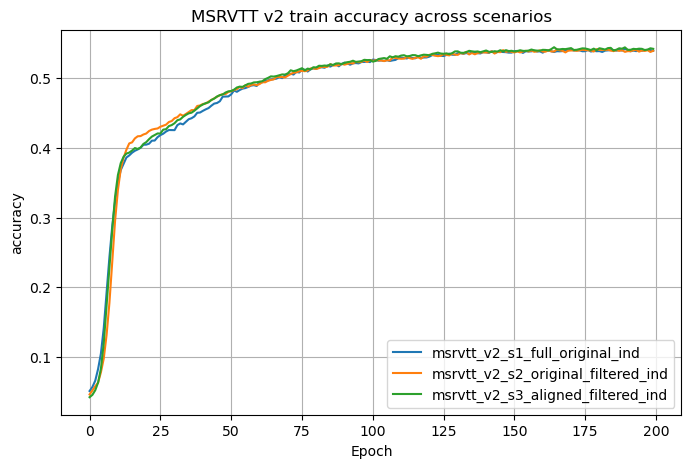

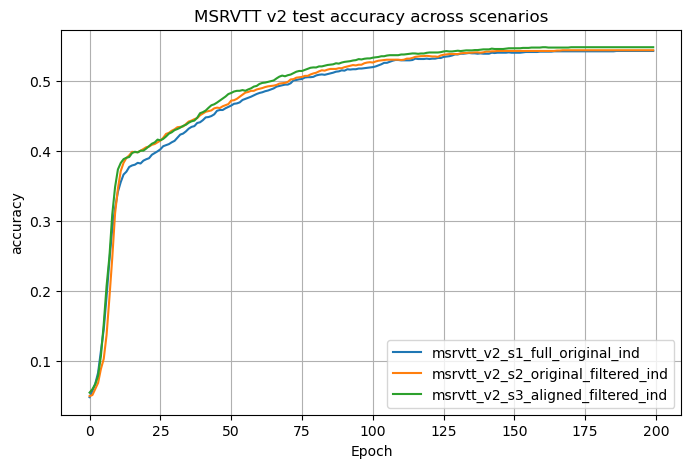

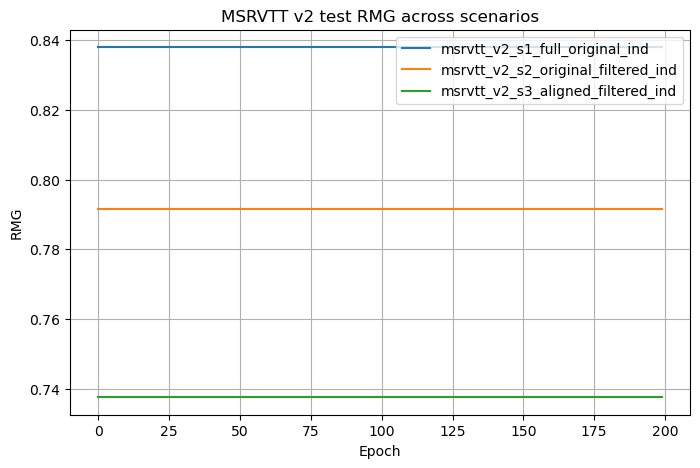

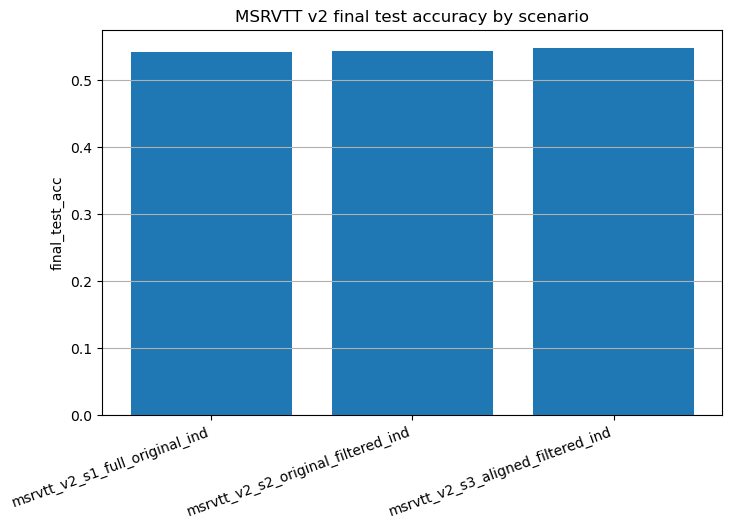

In [9]:
summary_df_v2 = build_summary_table(scenario_results_v2)
display(summary_df_v2)

plot_metric_history(scenario_results_v2, split="train", metric="accuracy",
                    title="MSRVTT v2 train accuracy across scenarios")
plot_metric_history(scenario_results_v2, split="test",  metric="accuracy",
                    title="MSRVTT v2 test accuracy across scenarios")
plot_metric_history(scenario_results_v2, split="test",  metric="RMG",
                    title="MSRVTT v2 test RMG across scenarios")
plot_final_metric_bars(summary_df_v2, metric="final_test_acc",
                       title="MSRVTT v2 final test accuracy by scenario")


### Run the models on the test set and get the values (loss and accuracy)

In [ ]:
scenario_configs_v2 = {
    "msrvtt_v2_s1_full_original_ind":     ("baseline",          embedding_dim_v2,           None,              None),
    "msrvtt_v2_s2_original_filtered_ind": ("original_filtered", int(len(selected_dims_v2)), selected_dims_v2,  None),
    "msrvtt_v2_s3_aligned_filtered_ind":  ("aligned_filtered",  int(len(selected_dims_v2)), selected_dims_v2,  sub_model_v2),
}

lut_gpu_v2 = label_lut_cpu_v2.to(DEVICE)
criterion_eval = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)

eval_results_v2 = {}

for scenario_name, (scenario_mode, feat_dim, sel_dims, s_model) in scenario_configs_v2.items():
    ckpt_path = BASE_SAVE_DIR / scenario_name / "best_model_test_acc.pt"
    if not ckpt_path.exists():
        print(f"[{scenario_name}] checkpoint not found at {ckpt_path}, skipping.")
        continue

    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model = LinearProbingIndependentModalities(d=feat_dim, num_classes=num_classes_v2).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    sel_dims_t = None
    if sel_dims is not None:
        sel_dims_t = torch.as_tensor(sel_dims, dtype=torch.long, device=DEVICE)

    losses, accs = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader_v2, desc=f"Eval {scenario_name}", leave=False):
            text_emb, vision_emb, labels = batch[:3]
            text_emb   = text_emb.to(device=DEVICE, dtype=torch.float32)
            vision_emb = vision_emb.to(device=DEVICE, dtype=torch.float32)
            labels = torch.as_tensor(labels, device=DEVICE, dtype=torch.long)
            labels = remap_labels(labels, lut_gpu_v2)

            text_feat, vision_feat = prepare_features_for_scenario(
                text_emb, vision_emb,
                scenario_mode=scenario_mode,
                selected_dims=sel_dims_t,
                sub_model=s_model,
                device=DEVICE,
            )

            all_emb    = torch.cat([text_feat, vision_feat], dim=0)
            all_labels = torch.cat([labels, labels], dim=0)

            logits = model(all_emb)
            loss = criterion_eval(logits, all_labels)
            acc  = (logits.argmax(dim=1) == all_labels).float().mean()

            losses.append(loss.item())
            accs.append(acc.item())

    test_loss = float(np.mean(losses))
    test_acc  = float(np.mean(accs))
    eval_results_v2[scenario_name] = {
        "test_loss": test_loss,
        "test_acc":  test_acc,
        "ckpt_epoch": ckpt.get("epoch", "?"),
        "feature_dim": feat_dim,
    }
    print(f"[{scenario_name}] test_loss={test_loss:.4f}  test_acc={test_acc:.4f}  "
          f"(ckpt epoch {ckpt.get('epoch', '?')})")

print("\n" + "=" * 80)
print(f"{'Scenario':<45s} {'Test Loss':>10s} {'Test Acc':>10s} {'Feat Dim':>10s}")
print("-" * 80)
for name, res in eval_results_v2.items():
    print(f"{name:<45s} {res['test_loss']:>10.4f} {res['test_acc']:>10.4f} {res['feature_dim']:>10d}")
print("=" * 80)


## Flickr30K

In [1]:
import copy
import json
import sys
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

try:
    import wandb
except ImportError as exc:
    raise ImportError("wandb is required. Install with `pip install wandb`.") from exc

sys.path.append(os.path.abspath(".."))
from sklearn.model_selection import train_test_split

from dataset.flickr30k.dataloader_embeddings_with_labels import EmbeddingsDatasetWithLabels
from dataset.flickr30k.flickr_imagenet_utils import original_idx2class
from metrics.clustering import _clustering_metrics_two_modalities_flickr30k
from subspace_alignment.subspace_alignment import (
    fit_subspace_alignment,
    apply_subspace_alignment,
    analyze_subspace_dimensions,
)
from analysis.modality_gap import compute_gap
from metrics.retrieval import compute_retrieval
from models.fusion_mlp_classifier import LinearProbingIndependentModalities

# ── Seed ──
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

# ── Device ──
DEVICE = os.environ.get("FLICKR_CLS_DEVICE", "cuda:1" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ── Constants ──
D_SUB = 256
NUM_WORKERS = 0
CLASSIFIER_EPOCHS = 200
CLASSIFIER_PATIENCE = 20
MAX_LR = 3e-4
WEIGHT_DECAY = 1e-4
WANDB_ENABLED = True
GAP_NAMES = ["RMG", "L2M", "L2I", "cosineTP"]

/opt/anaconda3/envs/few_dim_modalitygap/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda:1


In [2]:
# ── Helper functions ──
def label_to_int(label):
    if isinstance(label, torch.Tensor):
        return int(label.item())
    if isinstance(label, np.ndarray):
        return int(label.item())
    return int(label)


def extract_labels_from_dataset(dataset, desc="labels"):
    labels = []
    for idx in tqdm(range(len(dataset)), desc=desc):
        item = dataset[idx]
        if len(item) < 3:
            raise ValueError("Dataset must return at least (text, vision, label).")
        labels.append(label_to_int(item[2]))
    return np.asarray(labels, dtype=np.int64)


def gap_to_float(x):
    if isinstance(x, dict):
        if "text_vision" in x:
            return float(x["text_vision"])
        return float(next(iter(x.values())))
    if isinstance(x, torch.Tensor):
        return float(x.item())
    if hasattr(x, "item"):
        return float(x.item())
    return float(x)


def normalize01(v, eps=1e-12):
    v = np.asarray(v, dtype=np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)


def get_dims_gap(loader, max_samples=20_000, device="cuda:1"):
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Collecting up to {max_samples} train pairs"):
            text_b, vis_b = batch[:2]
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()
            Xs.append(text_b)
            Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break
    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]
    mu_x = X.mean(axis=0)
    mu_y = Y.mean(axis=0)
    gap_dim = np.abs(mu_x - mu_y)
    top_gap = np.argsort(-gap_dim)
    return normalize01(gap_dim), top_gap


def select_dims(importance, gap, imp_thr, gap_thr, min_dims=16):
    idx = np.where((importance >= imp_thr) & (gap <= gap_thr))[0]
    if idx.size < min_dims:
        order = np.argsort(-importance)
        idx = order[:min_dims]
    return np.sort(idx)


def make_optimizer_and_scheduler(model, train_loader, epochs=200, max_lr=3e-4, weight_decay=1e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=max_lr,
        epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,
        div_factor=25.0,
        final_div_factor=1e4,
        anneal_strategy="cos",
    )
    return optimizer, scheduler


def remap_labels(labels_gpu, lut_gpu):
    if labels_gpu.numel() == 0:
        return labels_gpu
    if labels_gpu.min().item() < 0 or labels_gpu.max().item() >= lut_gpu.numel():
        raise ValueError(
            f"Labels out of LUT range. min={labels_gpu.min().item()} "
            f"max={labels_gpu.max().item()} lut_size={lut_gpu.numel()}"
        )
    mapped = lut_gpu[labels_gpu]
    if (mapped < 0).any():
        bad = labels_gpu[mapped < 0][:20].detach().cpu().numpy()
        raise ValueError(f"Found labels missing from the train label map. Examples: {bad}")
    return mapped


def prepare_features_for_scenario(
    text_emb, vision_emb, scenario_mode,
    selected_dims=None, sub_model=None, device="cuda",
):
    if scenario_mode == "baseline":
        return text_emb, vision_emb
    if selected_dims is None:
        raise ValueError("selected_dims must be provided for filtered scenarios.")
    if scenario_mode == "original_filtered":
        return (
            text_emb.index_select(dim=1, index=selected_dims),
            vision_emb.index_select(dim=1, index=selected_dims),
        )
    if scenario_mode == "aligned_filtered":
        if sub_model is None:
            raise ValueError("sub_model required for aligned scenario.")
        X_al, _, Y_al = apply_subspace_alignment(text_emb, vision_emb, sub_model)
        return (
            X_al.index_select(dim=1, index=selected_dims),
            Y_al.index_select(dim=1, index=selected_dims),
        )
    raise ValueError(f"Unknown scenario_mode: {scenario_mode}")


def build_summary_table(results_dict):
    rows = []
    for scenario_name, result in results_dict.items():
        row = {
            "scenario": scenario_name,
            "feature_dim": result["feature_dim"],
            "selected_dims": result["selected_dims_count"],
            "removed_dims": result["removed_dims_count"],
            "best_test_acc": result["best_test_acc"],
            "best_test_loss": result["best_test_loss"],
            "final_train_acc": result["final_train_acc"],
            "final_test_acc": result["final_test_acc"],
            "final_train_loss": result["final_train_loss"],
            "final_test_loss": result["final_test_loss"],
        }
        for g in GAP_NAMES:
            row[f"train_{g}"] = result["final_train_gaps"][g]
            row[f"test_{g}"]  = result["final_test_gaps"][g]
        rows.append(row)
    return pd.DataFrame(rows).sort_values("scenario").reset_index(drop=True)


def plot_metric_history(results_dict, split, metric, title):
    plt.figure(figsize=(8, 5))
    for name, r in results_dict.items():
        plt.plot(r["history"][split][metric], label=name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_final_metric_bars(summary_df, metric, title):
    plt.figure(figsize=(8, 5))
    plt.bar(summary_df["scenario"], summary_df[metric])
    plt.title(title)
    plt.ylabel(metric)
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y")
    plt.show()


# ── Paths ──
FLICKR_PRECOMPUTED_DIR = "/mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/clip_vit_b_32___laion2b_s34b_b79k"

# ── W&B ──
WANDB_PROJECT_FLICKR = "flickr30k_clip_classifier"
WANDB_GROUP_FLICKR   = "flickr30k_linear_probe_independent"

BASE_SAVE_DIR_FLICKR = Path("flickr30k_classification_runs")
BASE_SAVE_DIR_FLICKR.mkdir(parents=True, exist_ok=True)

FLICKR_SEARCH_CFG = {
    "n_trials": 100,
    "seed": 0,
    "max_eval_batches": 40,
    "max_cluster_samples": 3000,
    "min_dims": 16,
    "direction": "text_to_vision",
}

# ── Load full dataset ──
ds_flickr_full = EmbeddingsDatasetWithLabels(
    precomputed_dir=FLICKR_PRECOMPUTED_DIR,
    split_name="flickr30k",
)
print(f"Full Flickr30K samples: {len(ds_flickr_full)}")

# ── Filter classes with < 10 samples ──
FLICKR_MIN_SAMPLES = 10
_class_counts_flickr = {}
for _, _, label in tqdm(ds_flickr_full, desc="Counting classes"):
    _class_counts_flickr[label.item()] = _class_counts_flickr.get(label.item(), 0) + 1

filtered_classes_flickr = {c for c, n in _class_counts_flickr.items() if n >= FLICKR_MIN_SAMPLES}
filtered_indices_flickr = [
    i for i, (_, _, label) in enumerate(ds_flickr_full)
    if label.item() in filtered_classes_flickr
]
ds_flickr_filtered = torch.utils.data.Subset(ds_flickr_full, filtered_indices_flickr)
print(f"Classes after filtering (>={FLICKR_MIN_SAMPLES}): {len(filtered_classes_flickr)}")
print(f"Samples after filtering: {len(ds_flickr_filtered)}")

# ── Stratified 80/20 train/test split ──
_filtered_labels_flickr = np.array([
    ds_flickr_full[i][2].item() for i in filtered_indices_flickr
])
_all_idx_flickr = np.arange(len(ds_flickr_filtered))
train_idx_flickr, test_idx_flickr, _, _ = train_test_split(
    _all_idx_flickr,
    _filtered_labels_flickr,
    test_size=0.20,
    stratify=_filtered_labels_flickr,
    random_state=SEED,
)

train_dataset_flickr = torch.utils.data.Subset(ds_flickr_filtered, train_idx_flickr)
test_dataset_flickr  = torch.utils.data.Subset(ds_flickr_filtered, test_idx_flickr)

# ── DataLoaders ──
BATCH_SIZE_FLICKR = 2048
g_flickr = torch.Generator().manual_seed(SEED)
train_loader_flickr = DataLoader(
    train_dataset_flickr,
    batch_size=BATCH_SIZE_FLICKR,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=g_flickr,
)
test_loader_flickr = DataLoader(
    test_dataset_flickr,
    batch_size=BATCH_SIZE_FLICKR,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

# ── Label remapping ──
flickr_unique_labels = sorted(set(
    extract_labels_from_dataset(train_dataset_flickr, desc="Extracting Flickr train labels")
))
num_classes_flickr = len(flickr_unique_labels)
embedding_dim_flickr = int(ds_flickr_full[0][0].shape[-1])

label_map_flickr = {orig: new for new, orig in enumerate(flickr_unique_labels)}
max_label_flickr = max(flickr_unique_labels)
label_lut_cpu_flickr = torch.full((max_label_flickr + 1,), -1, dtype=torch.long)
for orig, new in label_map_flickr.items():
    label_lut_cpu_flickr[orig] = new

n_clusters_flickr = num_classes_flickr
FLICKR_SEARCH_CFG["n_clusters"] = n_clusters_flickr

print(f"Train samples (Flickr30K): {len(train_dataset_flickr)}")
print(f"Test  samples (Flickr30K): {len(test_dataset_flickr)}")
print(f"Number of classes         : {num_classes_flickr}")
print(f"Embedding dim             : {embedding_dim_flickr}")

[Loaded] 31783 samples from /mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/clip_vit_b_32___laion2b_s34b_b79k
Full Flickr30K samples: 31783


Counting classes: 100%|██████████| 31783/31783 [00:00<00:00, 154398.38it/s]


Classes after filtering (>=10): 465
Samples after filtering: 30471


Extracting Flickr train labels: 100%|██████████| 24376/24376 [00:00<00:00, 147455.10it/s]

Train samples (Flickr30K): 24376
Test  samples (Flickr30K): 6095
Number of classes         : 465
Embedding dim             : 512


In [3]:
def eval_thresholds_flickr30k(
    imp_thr,
    gap_thr,
    test_loader,
    sub_model,
    important_joint_dims,
    gap_dims,
    device="cuda",
    max_eval_batches=None,
    max_cluster_samples=3000,
    n_clusters=None,
    direction="text_to_vision",
    min_dims=16,
):
    idx = select_dims(important_joint_dims, gap_dims, imp_thr, gap_thr, min_dims=min_dims)

    r_orig    = {1: [], 5: [], 10: []}
    r_aligned = {1: [], 5: [], 10: []}
    gaps_orig_batches    = {g: [] for g in GAP_NAMES}
    gaps_aligned_batches = {g: [] for g in GAP_NAMES}

    Xt_buf, Xv_buf, Xv_al_buf, labels_buf = [], [], [], []
    seen = 0
    n_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Flickr30K threshold evaluation", leave=False):
            text_b, vis_b, labels = batch[:3]
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device),  dim=-1)

            if direction == "vision_to_text":
                X, Y = Y, X

            Xs = X[:, idx]
            Ys = Y[:, idx]

            r_orig[1].append(gap_to_float(compute_retrieval("flickr30k", (Xs, Ys), top_k=1)))
            r_orig[5].append(gap_to_float(compute_retrieval("flickr30k", (Xs, Ys), top_k=5)))
            r_orig[10].append(gap_to_float(compute_retrieval("flickr30k", (Xs, Ys), top_k=10)))

            Xn, _, Yaln = apply_subspace_alignment(X, Y, sub_model)
            Xal_s = Xn[:, idx]
            Yal_s = Yaln[:, idx]

            r_aligned[1].append(gap_to_float(compute_retrieval("flickr30k", (Xal_s, Yal_s), top_k=1)))
            r_aligned[5].append(gap_to_float(compute_retrieval("flickr30k", (Xal_s, Yal_s), top_k=5)))
            r_aligned[10].append(gap_to_float(compute_retrieval("flickr30k", (Xal_s, Yal_s), top_k=10)))

            for gap_name in GAP_NAMES:
                gaps_orig_batches[gap_name].append(
                    gap_to_float(compute_gap(gap_name, Xs, Ys, iterations=None))
                )
                gaps_aligned_batches[gap_name].append(
                    gap_to_float(compute_gap(gap_name, Xal_s, Yal_s, iterations=None))
                )

            if labels is not None and seen < max_cluster_samples:
                labels_t = torch.as_tensor(labels)
                b = min(Xs.shape[0], max_cluster_samples - seen)
                Xt_buf.append(Xs[:b].detach().cpu())
                Xv_buf.append(Ys[:b].detach().cpu())
                Xv_al_buf.append(Yal_s[:b].detach().cpu())
                labels_buf.append(labels_t[:b].detach().cpu())
                seen += b

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    clustering_orig = None
    clustering_aligned = None
    if labels_buf:
        Xt_all     = torch.cat(Xt_buf, dim=0)
        Xv_all     = torch.cat(Xv_buf, dim=0)
        Xv_al_all  = torch.cat(Xv_al_buf, dim=0)
        labels_all = torch.cat(labels_buf, dim=0)
        clustering_orig = _clustering_metrics_two_modalities_flickr30k(
            Xt_all, Xv_all, labels_all, n_clusters=n_clusters
        )
        clustering_aligned = _clustering_metrics_two_modalities_flickr30k(
            Xt_all, Xv_al_all, labels_all, n_clusters=n_clusters
        )

    return {
        "n_dims":             int(idx.size),
        "dim_idx":            idx,
        "retrieval_orig":     {k: float(np.mean(v)) for k, v in r_orig.items()},
        "retrieval_aligned":  {k: float(np.mean(v)) for k, v in r_aligned.items()},
        "gaps_orig":          {g: float(np.mean(v)) for g, v in gaps_orig_batches.items()},
        "gaps_aligned":       {g: float(np.mean(v)) for g, v in gaps_aligned_batches.items()},
        "clustering_orig":    clustering_orig,
        "clustering_aligned": clustering_aligned,
    }

In [4]:
# ── Fit subspace alignment on training data ──
print("Fitting Flickr30K subspace alignment model...")
sub_model_flickr = fit_subspace_alignment(train_loader_flickr, n_fit=10_000, d_sub=256, device=DEVICE)

important_dims_txt_flickr, important_dims_img_flickr, important_joint_dims_flickr = analyze_subspace_dimensions(
    sub_model_flickr, device=DEVICE,
)

Fitting Flickr30K subspace alignment model...


Collected 10000 samples of dimension 512, these will be used to fit the subspace alignment model with d_sub=256.


Best Flickr30K thresholds:
  imp_thr: 0.2676
  gap_thr: 0.8461
  selected_dims: 501
  removed_dims: 11
  best_score: 1.278051183558063
  retrieval_orig@1: 0.6823903520901998
  retrieval_aligned@1: 0.6674275596936544
  v_measure_orig: 0.5910167587269661
  v_measure_aligned: 0.6152676966053054
First 20 selected dims: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
First 20 removed dims : [34, 70, 152, 241, 244, 253, 285, 307, 442, 466, 496]


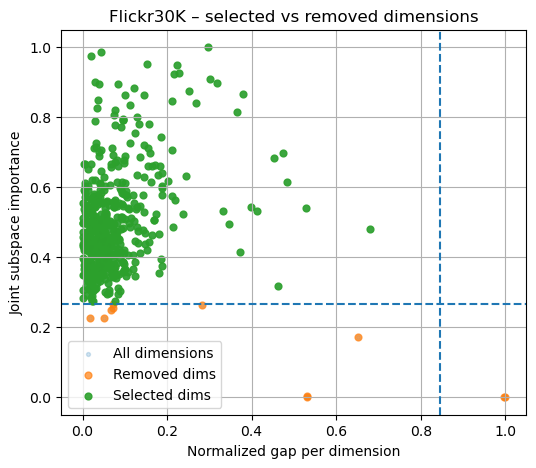

In [5]:
gap_dims_flickr, top_gap_idx_flickr = get_dims_gap(train_loader_flickr, device=DEVICE)

# ── Thresholds from few_dimensions.ipynb Flickr30K Optuna search ──
imp_thr_flickr = 0.2676
gap_thr_flickr = 0.8461

metrics_flickr = eval_thresholds_flickr30k(
    imp_thr=imp_thr_flickr,
    gap_thr=gap_thr_flickr,
    test_loader=test_loader_flickr,
    sub_model=sub_model_flickr,
    important_joint_dims=important_joint_dims_flickr,
    gap_dims=gap_dims_flickr,
    device=DEVICE,
    max_eval_batches=FLICKR_SEARCH_CFG["max_eval_batches"],
    max_cluster_samples=FLICKR_SEARCH_CFG["max_cluster_samples"],
    n_clusters=FLICKR_SEARCH_CFG["n_clusters"],
    direction=FLICKR_SEARCH_CFG["direction"],
    min_dims=FLICKR_SEARCH_CFG["min_dims"],
)

r1_orig_flickr    = metrics_flickr["retrieval_orig"][1]
r1_aligned_flickr = metrics_flickr["retrieval_aligned"][1]
v_orig_flickr    = metrics_flickr["clustering_orig"]["V-measure"]    if metrics_flickr["clustering_orig"]    else 0.0
v_aligned_flickr = metrics_flickr["clustering_aligned"]["V-measure"] if metrics_flickr["clustering_aligned"] else 0.0

selected_dims_flickr   = np.asarray(metrics_flickr["dim_idx"], dtype=np.int64)
removed_dims_flickr    = np.setdiff1d(np.arange(embedding_dim_flickr), selected_dims_flickr)
selected_dims_flickr_t = torch.as_tensor(selected_dims_flickr, dtype=torch.long, device=DEVICE)

dimension_search_summary_flickr = {
    "imp_thr":             imp_thr_flickr,
    "gap_thr":             gap_thr_flickr,
    "selected_dims":       int(selected_dims_flickr.size),
    "removed_dims":        int(removed_dims_flickr.size),
    "best_score":          0.5 * (r1_orig_flickr + r1_aligned_flickr) + 0.5 * (v_orig_flickr + v_aligned_flickr),
    "retrieval_orig@1":    float(r1_orig_flickr),
    "retrieval_aligned@1": float(r1_aligned_flickr),
    "v_measure_orig":      float(v_orig_flickr),
    "v_measure_aligned":   float(v_aligned_flickr),
}

print("Best Flickr30K thresholds:")
for key, value in dimension_search_summary_flickr.items():
    print(f"  {key}: {value}")

print("First 20 selected dims:", selected_dims_flickr[:20].tolist())
print("First 20 removed dims :", removed_dims_flickr[:20].tolist())

plt.figure(figsize=(6, 5))
plt.scatter(gap_dims_flickr, important_joint_dims_flickr, s=8, alpha=0.2, label="All dimensions")
removed_mask_flickr = np.ones_like(gap_dims_flickr, dtype=bool)
removed_mask_flickr[selected_dims_flickr] = False
plt.scatter(gap_dims_flickr[removed_mask_flickr], important_joint_dims_flickr[removed_mask_flickr],
            s=24, alpha=0.7, label="Removed dims")
plt.scatter(gap_dims_flickr[selected_dims_flickr], important_joint_dims_flickr[selected_dims_flickr],
            s=24, alpha=0.9, label="Selected dims")
plt.axvline(gap_thr_flickr, linestyle="--")
plt.axhline(imp_thr_flickr, linestyle="--")
plt.xlabel("Normalized gap per dimension")
plt.ylabel("Joint subspace importance")
plt.title("Flickr30K \u2013 selected vs removed dimensions")
plt.grid(True)
plt.legend()
plt.show()


In [6]:
def train_linear_probe_flickr30k_independent(
    scenario_name,
    scenario_mode,
    train_loader,
    test_loader,
    num_classes,
    feature_dim,
    device="cuda",
    selected_dims=None,
    sub_model=None,
    epochs=200,
    patience=20,
    max_lr=3e-4,
    weight_decay=1e-4,
    wandb_enabled=True,
    wandb_project="flickr30k_clip_classifier",
    wandb_group="flickr30k_linear_probe_independent",
    extra_config=None,
):
    scenario_dir = BASE_SAVE_DIR_FLICKR / scenario_name
    scenario_dir.mkdir(parents=True, exist_ok=True)

    model = LinearProbingIndependentModalities(d=feature_dim, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(device)
    optimizer, scheduler = make_optimizer_and_scheduler(
        model, train_loader, epochs=epochs, max_lr=max_lr, weight_decay=weight_decay,
    )

    lut_gpu = label_lut_cpu_flickr.to(device)
    selected_dims_t = None
    if selected_dims is not None:
        selected_dims_t = torch.as_tensor(selected_dims, dtype=torch.long, device=device)

    run_config = {
        "scenario_name": scenario_name,
        "scenario_mode": scenario_mode,
        "feature_dim": int(feature_dim),
        "num_classes": int(num_classes),
        "epochs": int(epochs),
        "patience": int(patience),
        "max_lr": float(max_lr),
        "weight_decay": float(weight_decay),
        "d_sub": int(D_SUB),
        "selected_dims_count": int(len(selected_dims)) if selected_dims is not None else int(embedding_dim_flickr),
        "independent_modalities": True,
        "dataset_version": "flickr30k",
    }
    if extra_config is not None:
        run_config.update(extra_config)

    run = None
    if wandb_enabled:
        run = wandb.init(
            project=wandb_project,
            group=wandb_group,
            name=scenario_name,
            config=run_config,
            reinit=True,
        )

    history = {
        "train": {"loss": [], "accuracy": [], "lr": [], **{g: [] for g in GAP_NAMES}},
        "test":  {"loss": [], "accuracy": [], **{g: [] for g in GAP_NAMES}},
    }

    best_test_loss = float("inf")
    best_test_acc  = 0.0
    best_loss_state = None
    best_acc_state  = None
    epochs_no_improve = 0

    def run_epoch(dataloader, phase):
        is_train = phase == "train"
        model.train() if is_train else model.eval()
        losses, accs, lrs = [], [], []
        gap_values = {g: [] for g in GAP_NAMES}

        for batch in tqdm(dataloader, desc=f"{scenario_name} | {phase}", leave=False):
            text_emb, vision_emb, labels = batch[:3]
            text_emb   = text_emb.to(device=device, dtype=torch.float32, non_blocking=True)
            vision_emb = vision_emb.to(device=device, dtype=torch.float32, non_blocking=True)
            labels = torch.as_tensor(labels, device=device, dtype=torch.long)
            labels = remap_labels(labels, lut_gpu)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            text_feat, vision_feat = prepare_features_for_scenario(
                text_emb, vision_emb,
                scenario_mode=scenario_mode,
                selected_dims=selected_dims_t,
                sub_model=sub_model,
                device=device,
            )

            # Independent modality: each modality is its own sample
            all_emb    = torch.cat([text_feat, vision_feat], dim=0)   # (2B, d)
            all_labels = torch.cat([labels, labels], dim=0)           # (2B,)

            logits = model(all_emb)                                   # (2B, C)
            loss = criterion(logits, all_labels)

            if is_train:
                loss.backward()
                clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            acc = (logits.argmax(dim=1) == all_labels).float().mean()
            losses.append(float(loss.item()))
            accs.append(float(acc.item()))
            if is_train:
                lrs.append(float(optimizer.param_groups[0]["lr"]))

            with torch.no_grad():
                for gap_name in GAP_NAMES:
                    gap_values[gap_name].append(
                        gap_to_float(compute_gap(gap_name, text_feat.detach(), vision_feat.detach(), iterations=None))
                    )

        mean_loss = float(np.mean(losses)) if losses else float("nan")
        mean_acc  = float(np.mean(accs))   if accs   else float("nan")
        mean_lr   = float(np.mean(lrs))    if (is_train and lrs) else None
        mean_gaps = {g: float(np.mean(v))  for g, v in gap_values.items()}
        return mean_loss, mean_acc, mean_lr, mean_gaps

    for epoch in range(epochs):
        train_loss, train_acc, train_lr, train_gaps = run_epoch(train_loader, phase="train")
        with torch.no_grad():
            test_loss, test_acc, _, test_gaps = run_epoch(test_loader, phase="test")

        history["train"]["loss"].append(train_loss)
        history["train"]["accuracy"].append(train_acc)
        history["train"]["lr"].append(train_lr if train_lr is not None else float("nan"))
        for g in GAP_NAMES:
            history["train"][g].append(train_gaps[g])

        history["test"]["loss"].append(test_loss)
        history["test"]["accuracy"].append(test_acc)
        for g in GAP_NAMES:
            history["test"][g].append(test_gaps[g])

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(
                f"[{scenario_name}] epoch {epoch+1}/{epochs} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}"
            )

        improved = False
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_loss_state = copy.deepcopy(model.state_dict())
            improved = True
            torch.save({
                "epoch": epoch + 1, "metric": "test_loss",
                "metric_value": best_test_loss,
                "model_state_dict": best_loss_state,
                "config": run_config,
            }, scenario_dir / "best_model_test_loss.pt")

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_acc_state = copy.deepcopy(model.state_dict())
            improved = True
            torch.save({
                "epoch": epoch + 1, "metric": "test_accuracy",
                "metric_value": best_test_acc,
                "model_state_dict": best_acc_state,
                "config": run_config,
            }, scenario_dir / "best_model_test_acc.pt")

        if improved:
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if run is not None:
            payload = {
                "epoch": epoch + 1,
                "train/loss": train_loss, "train/accuracy": train_acc, "train/lr": train_lr,
                "test/loss": test_loss, "test/accuracy": test_acc,
                "best/test_loss": best_test_loss, "best/test_accuracy": best_test_acc,
                "early_stop/epochs_no_improve": epochs_no_improve,
            }
            for g in GAP_NAMES:
                payload[f"train/{g}"] = train_gaps[g]
                payload[f"test/{g}"]  = test_gaps[g]
            wandb.log(payload)

        if epochs_no_improve >= patience:
            print(f"[{scenario_name}] early stop at epoch {epoch+1}/{epochs}")
            break

    if best_acc_state is not None:
        model.load_state_dict(best_acc_state)
        best_checkpoint_metric = "test_accuracy"
    elif best_loss_state is not None:
        model.load_state_dict(best_loss_state)
        best_checkpoint_metric = "test_loss"
    else:
        best_checkpoint_metric = "last_epoch"

    with torch.no_grad():
        final_train_loss, final_train_acc, _, final_train_gaps = run_epoch(train_loader, phase="test")
        final_test_loss,  final_test_acc,  _, final_test_gaps  = run_epoch(test_loader,  phase="test")

    result = {
        "scenario_name": scenario_name,
        "scenario_mode": scenario_mode,
        "feature_dim": int(feature_dim),
        "selected_dims_count": int(len(selected_dims)) if selected_dims is not None else int(embedding_dim_flickr),
        "removed_dims_count": int(embedding_dim_flickr - len(selected_dims)) if selected_dims is not None else 0,
        "best_checkpoint_metric": best_checkpoint_metric,
        "best_test_loss": float(best_test_loss),
        "best_test_acc": float(best_test_acc),
        "final_train_loss": float(final_train_loss),
        "final_train_acc": float(final_train_acc),
        "final_test_loss": float(final_test_loss),
        "final_test_acc": float(final_test_acc),
        "final_train_gaps": {k: float(v) for k, v in final_train_gaps.items()},
        "final_test_gaps":  {k: float(v) for k, v in final_test_gaps.items()},
        "history": history,
        "checkpoint_dir": str(scenario_dir),
    }

    with open(scenario_dir / "summary.json", "w") as f:
        json.dump(result, f, indent=2)

    torch.save({
        "model_state_dict": model.state_dict(),
        "result": result,
        "config": run_config,
    }, scenario_dir / "best_model_loaded_final.pt")

    if run is not None:
        run.summary["best_test_loss"]      = result["best_test_loss"]
        run.summary["best_test_acc"]       = result["best_test_acc"]
        run.summary["final_train_acc"]     = result["final_train_acc"]
        run.summary["final_test_acc"]      = result["final_test_acc"]
        run.summary["selected_dims_count"] = result["selected_dims_count"]
        run.summary["removed_dims_count"]  = result["removed_dims_count"]
        for g in GAP_NAMES:
            run.summary[f"final_train_{g}"] = result["final_train_gaps"][g]
            run.summary[f"final_test_{g}"]  = result["final_test_gaps"][g]
        run.finish()

    print(
        f"[{scenario_name}] done | best_test_acc={result['best_test_acc']:.4f} | "
        f"final_test_acc={result['final_test_acc']:.4f}"
    )
    return result


scenario_results_flickr = {}


### Baseline
Train the classifier on the original clip embeddings (full dims).

In [7]:
scenario_results_flickr["flickr30k_s1_full_original_ind"] = train_linear_probe_flickr30k_independent(
    scenario_name="flickr30k_s1_full_original_ind",
    scenario_mode="baseline",
    train_loader=train_loader_flickr,
    test_loader=test_loader_flickr,
    num_classes=num_classes_flickr,
    feature_dim=embedding_dim_flickr,
    device=DEVICE,
    epochs=CLASSIFIER_EPOCHS,
    patience=CLASSIFIER_PATIENCE,
    max_lr=MAX_LR,
    weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project=WANDB_PROJECT_FLICKR,
    wandb_group=WANDB_GROUP_FLICKR,
    extra_config={
        "selected_dims_source": "none",
        "notes": "Linear probe on the original full Flickr30K embeddings.",
    },
)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/emanuele/.netrc.
wandb: Currently logged in as: rucci-emanuele (rucci-emanuele-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[flickr30k_s1_full_original_ind] epoch 1/200 | train_loss=6.1665 train_acc=0.0016 | test_loss=6.1593 test_acc=0.0020


[flickr30k_s1_full_original_ind] epoch 11/200 | train_loss=5.7766 train_acc=0.0950 | test_loss=5.7403 test_acc=0.1115


[flickr30k_s1_full_original_ind] epoch 21/200 | train_loss=4.7803 train_acc=0.2938 | test_loss=4.7872 test_acc=0.2808


[flickr30k_s1_full_original_ind] epoch 31/200 | train_loss=4.0625 train_acc=0.3493 | test_loss=4.1471 test_acc=0.3237


...

[flickr30k_s1_full_original_ind] epoch 191/200 | train_loss=2.7382 train_acc=0.5309 | test_loss=3.1921 test_acc=0.4187


[flickr30k_s1_full_original_ind] epoch 200/200 | train_loss=2.7379 train_acc=0.5309 | test_loss=3.1920 test_acc=0.4187


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/test_accuracy,▁▁▁▄▄▆▆▇▇▇▇█████████████████████████████
best/test_loss,█▆▄▄▄▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
early_stop/epochs_no_improve,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█
test/L2I,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/L2M,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/RMG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁▁▂▅▆▆▆▇▇▇▇█████████████████████████████
test/cosineTP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/loss,█▇▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+7,...


[flickr30k_s1_full_original_ind] done | best_test_acc=0.4187 | final_test_acc=0.4187


### Original space subdimensions

In [8]:
scenario_results_flickr["flickr30k_s2_original_filtered_ind"] = train_linear_probe_flickr30k_independent(
    scenario_name="flickr30k_s2_original_filtered_ind",
    scenario_mode="original_filtered",
    train_loader=train_loader_flickr,
    test_loader=test_loader_flickr,
    num_classes=num_classes_flickr,
    feature_dim=int(len(selected_dims_flickr)),
    device=DEVICE,
    selected_dims=selected_dims_flickr,
    sub_model=None,
    epochs=CLASSIFIER_EPOCHS,
    patience=CLASSIFIER_PATIENCE,
    max_lr=MAX_LR,
    weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project=WANDB_PROJECT_FLICKR,
    wandb_group=WANDB_GROUP_FLICKR,
    extra_config={
        "selected_dims_source": "few_dimensions_flickr30k_threshold_search",
        "imp_thr": imp_thr_flickr,
        "gap_thr": gap_thr_flickr,
        "notes": "Independent modalities linear probe on the original Flickr30K embeddings "
                 "after removing the dimensions discarded by the subspace-based selector.",
    },
)


[flickr30k_s2_original_filtered_ind] epoch 1/200 | train_loss=6.1719 train_acc=0.0023 | test_loss=6.1674 test_acc=0.0013


[flickr30k_s2_original_filtered_ind] epoch 11/200 | train_loss=5.8028 train_acc=0.0927 | test_loss=5.7700 test_acc=0.1087


[flickr30k_s2_original_filtered_ind] epoch 21/200 | train_loss=4.8148 train_acc=0.3058 | test_loss=4.8228 test_acc=0.2858


[flickr30k_s2_original_filtered_ind] epoch 31/200 | train_loss=4.0868 train_acc=0.3532 | test_loss=4.1695 test_acc=0.3242


[flickr30k_s2_original_filtered_ind] epoch 41/200 | train_loss=3.6550 train_acc=0.3943 | test_loss=3.8010 test_acc=0.3558


...

[flickr30k_s2_original_filtered_ind] epoch 191/200 | train_loss=2.7480 train_acc=0.5281 | test_loss=3.1964 test_acc=0.4174


[flickr30k_s2_original_filtered_ind] epoch 200/200 | train_loss=2.7481 train_acc=0.5281 | test_loss=3.1964 test_acc=0.4173


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/test_accuracy,▁▁▂▄▅▆▇▇▇▇▇▇████████████████████████████
best/test_loss,██▇▆▅▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
early_stop/epochs_no_improve,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇██
test/L2I,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/L2M,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/RMG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁▁▂▂▅▆▆▆▇▇▇▇▇▇██████████████████████████
test/cosineTP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/loss,███▇▆▆▅▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+7,...


[flickr30k_s2_original_filtered_ind] done | best_test_acc=0.4175 | final_test_acc=0.4175


### Aligned space subdimensions

In [9]:
scenario_results_flickr["flickr30k_s3_aligned_filtered_ind"] = train_linear_probe_flickr30k_independent(
    scenario_name="flickr30k_s3_aligned_filtered_ind",
    scenario_mode="aligned_filtered",
    train_loader=train_loader_flickr,
    test_loader=test_loader_flickr,
    num_classes=num_classes_flickr,
    feature_dim=int(len(selected_dims_flickr)),
    device=DEVICE,
    selected_dims=selected_dims_flickr,
    sub_model=sub_model_flickr,
    epochs=CLASSIFIER_EPOCHS,
    patience=CLASSIFIER_PATIENCE,
    max_lr=MAX_LR,
    weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project=WANDB_PROJECT_FLICKR,
    wandb_group=WANDB_GROUP_FLICKR,
    extra_config={
        "selected_dims_source": "few_dimensions_flickr30k_threshold_search",
        "imp_thr": imp_thr_flickr,
        "gap_thr": gap_thr_flickr,
        "notes": "Independent modalities linear probe on the aligned Flickr30K embeddings "
                 "after removing the dimensions discarded by the subspace-based selector.",
    },
)


[flickr30k_s3_aligned_filtered_ind] epoch 1/200 | train_loss=6.1439 train_acc=0.0015 | test_loss=6.1432 test_acc=0.0016


[flickr30k_s3_aligned_filtered_ind] epoch 11/200 | train_loss=6.0885 train_acc=0.0679 | test_loss=6.0825 test_acc=0.0798


[flickr30k_s3_aligned_filtered_ind] epoch 21/200 | train_loss=5.8990 train_acc=0.2750 | test_loss=5.8935 test_acc=0.2696


[flickr30k_s3_aligned_filtered_ind] epoch 31/200 | train_loss=5.6936 train_acc=0.3032 | test_loss=5.6953 test_acc=0.2898


[flickr30k_s3_aligned_filtered_ind] epoch 41/200 | train_loss=5.5078 train_acc=0.3089 | test_loss=5.5164 test_acc=0.2917


...

[flickr30k_s3_aligned_filtered_ind] epoch 191/200 | train_loss=4.5062 train_acc=0.3186 | test_loss=4.5712 test_acc=0.2990


[flickr30k_s3_aligned_filtered_ind] epoch 200/200 | train_loss=4.5060 train_acc=0.3186 | test_loss=4.5710 test_acc=0.2990


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/test_accuracy,▁▂▃▆▇███████████████████████████████████
best/test_loss,███▇▇▆▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
early_stop/epochs_no_improve,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇████
test/L2I,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/L2M,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/RMG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁▁▁▂▃▇██████████████████████████████████
test/cosineTP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/loss,███▇▇▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
+7,...


[flickr30k_s3_aligned_filtered_ind] done | best_test_acc=0.2991 | final_test_acc=0.2991


### EXP recap

,scenario,feature_dim,selected_dims,removed_dims,best_test_acc,best_test_loss,final_train_acc,final_test_acc,final_train_loss,final_test_loss,train_RMG,test_RMG,train_L2M,test_L2M,train_L2I,test_L2I,train_cosineTP,test_cosineTP
0,flickr30k_s1_full_original_ind,512,512,0,0.418722,3.192029,0.531052,0.418722,2.737839,3.192103,0.797638,0.797728,6.227245,6.250275,10.493245,10.486827,0.322145,0.322764
1,flickr30k_s2_original_filtered_ind,501,501,11,0.417501,3.196397,0.527103,0.417501,2.751903,3.197730,0.776342,0.776385,4.904156,4.926351,9.598068,9.592028,0.334032,0.334761
2,flickr30k_s3_aligned_filtered_ind,501,501,11,0.299104,4.571027,0.318252,0.299104,4.515424,4.579854,0.742996,0.742881,0.469057,0.471128,1.050545,1.049765,0.408973,0.410261


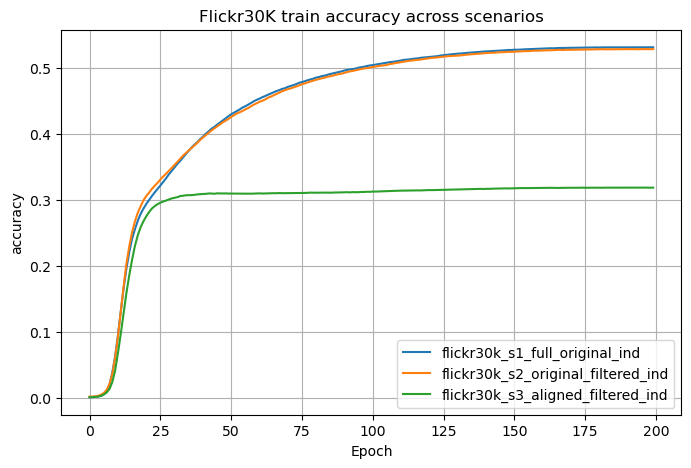

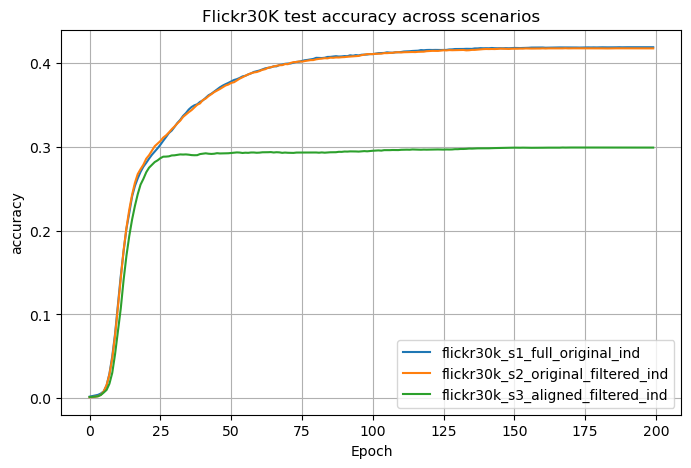

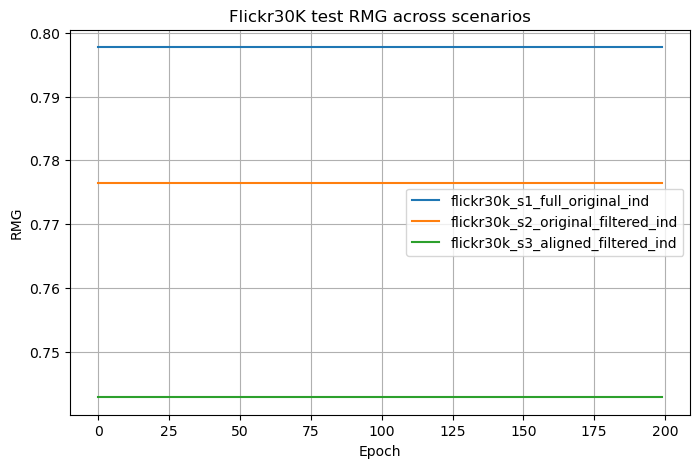

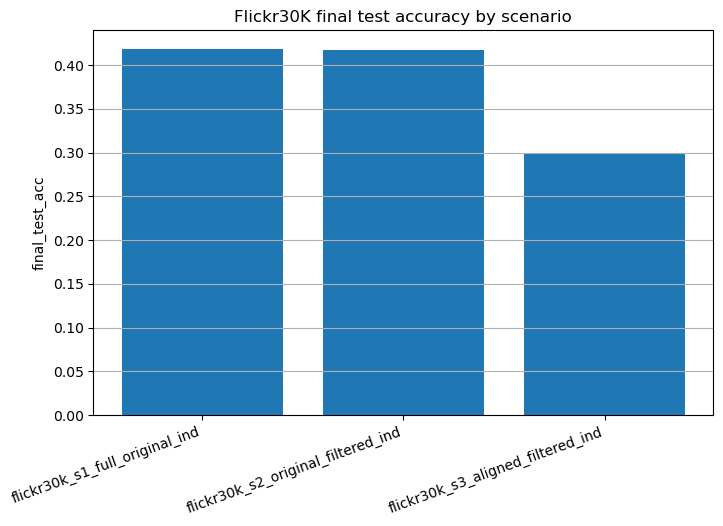

In [10]:
summary_df_flickr = build_summary_table(scenario_results_flickr)
display(summary_df_flickr)

plot_metric_history(scenario_results_flickr, split="train", metric="accuracy",
                    title="Flickr30K train accuracy across scenarios")
plot_metric_history(scenario_results_flickr, split="test",  metric="accuracy",
                    title="Flickr30K test accuracy across scenarios")
plot_metric_history(scenario_results_flickr, split="test",  metric="RMG",
                    title="Flickr30K test RMG across scenarios")
plot_final_metric_bars(summary_df_flickr, metric="final_test_acc",
                       title="Flickr30K final test accuracy by scenario")


### Run the models on the test set and get the values (loss and accuracy)

In [11]:
scenario_configs_flickr = {
    "flickr30k_s1_full_original_ind":     ("baseline",          embedding_dim_flickr,              None,               None),
    "flickr30k_s2_original_filtered_ind": ("original_filtered", int(len(selected_dims_flickr)),     selected_dims_flickr, None),
    "flickr30k_s3_aligned_filtered_ind":  ("aligned_filtered",  int(len(selected_dims_flickr)),     selected_dims_flickr, sub_model_flickr),
}

lut_gpu_flickr = label_lut_cpu_flickr.to(DEVICE)
criterion_eval_flickr = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)

eval_results_flickr = {}

for scenario_name, (scenario_mode, feat_dim, sel_dims, s_model) in scenario_configs_flickr.items():
    ckpt_path = BASE_SAVE_DIR_FLICKR / scenario_name / "best_model_test_acc.pt"
    if not ckpt_path.exists():
        print(f"[{scenario_name}] checkpoint not found at {ckpt_path}, skipping.")
        continue

    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model = LinearProbingIndependentModalities(d=feat_dim, num_classes=num_classes_flickr).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    sel_dims_t = None
    if sel_dims is not None:
        sel_dims_t = torch.as_tensor(sel_dims, dtype=torch.long, device=DEVICE)

    losses, accs = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader_flickr, desc=f"Eval {scenario_name}", leave=False):
            text_emb, vision_emb, labels = batch[:3]
            text_emb   = text_emb.to(device=DEVICE, dtype=torch.float32)
            vision_emb = vision_emb.to(device=DEVICE, dtype=torch.float32)
            labels = torch.as_tensor(labels, device=DEVICE, dtype=torch.long)
            labels = remap_labels(labels, lut_gpu_flickr)

            text_feat, vision_feat = prepare_features_for_scenario(
                text_emb, vision_emb,
                scenario_mode=scenario_mode,
                selected_dims=sel_dims_t,
                sub_model=s_model,
                device=DEVICE,
            )

            all_emb    = torch.cat([text_feat, vision_feat], dim=0)
            all_labels = torch.cat([labels, labels], dim=0)

            logits = model(all_emb)
            loss = criterion_eval_flickr(logits, all_labels)
            acc  = (logits.argmax(dim=1) == all_labels).float().mean()

            losses.append(loss.item())
            accs.append(acc.item())

    test_loss = float(np.mean(losses))
    test_acc  = float(np.mean(accs))
    eval_results_flickr[scenario_name] = {
        "test_loss": test_loss,
        "test_acc":  test_acc,
        "ckpt_epoch": ckpt.get("epoch", "?"),
        "feature_dim": feat_dim,
    }
    print(f"[{scenario_name}] test_loss={test_loss:.4f}  test_acc={test_acc:.4f}  "
          f"(ckpt epoch {ckpt.get('epoch', '?')})")

print("\n" + "=" * 80)
print(f"{'Scenario':<45s} {'Test Loss':>10s} {'Test Acc':>10s} {'Feat Dim':>10s}")
print("-" * 80)
for name, res in eval_results_flickr.items():
    print(f"{name:<45s} {res['test_loss']:>10.4f} {res['test_acc']:>10.4f} {res['feature_dim']:>10d}")
print("=" * 80)


[flickr30k_s1_full_original_ind] test_loss=3.1921  test_acc=0.4187  (ckpt epoch 188)


[flickr30k_s2_original_filtered_ind] test_loss=3.1977  test_acc=0.4175  (ckpt epoch 169)


[flickr30k_s3_aligned_filtered_ind] test_loss=4.5799  test_acc=0.2991  (ckpt epoch 168)

Scenario                                       Test Loss   Test Acc   Feat Dim
--------------------------------------------------------------------------------
flickr30k_s1_full_original_ind                    3.1921     0.4187        512
flickr30k_s2_original_filtered_ind                3.1977     0.4175        501
flickr30k_s3_aligned_filtered_ind                 4.5799     0.2991        501
